# Proyecto EDA — Campañas de marketing bancario

**Análisis Exploratorio de Datos (EDA) con Python y Pandas**

Este cuaderno documenta, paso a paso y explicando el *porqué* de cada decisión, el
análisis exploratorio de las campañas de marketing telefónico de una institución
bancaria portuguesa cuyo objetivo era que el cliente suscribiese un **depósito a
plazo** (variable objetivo `y`).

## Objetivo del análisis

Responder a la pregunta de negocio: **¿qué caracteriza a los clientes que sí
suscriben el depósito?** Es decir, qué variables (perfil del cliente, canal de
contacto, historial de campañas, contexto macroeconómico) se asocian con una mayor
tasa de conversión.

## Conjuntos de datos

- **`bank-additional.csv`** — 43.000 registros, uno por interacción de campaña.
- **`customer-details.xlsx`** — 3 hojas (`2012`, `2013`, `2014`) con los datos
  demográficos y de comportamiento de los clientes. Se cruzan con el CSV por el
  identificador único de cliente.

## Índice

0. Importaciones y configuración
1. Carga de datos
2. Exploración inicial
3. Limpieza y transformación de `bank-additional`
4. Limpieza y transformación de `customer-details`
5. Unión de los dos conjuntos (`merge`)
6. Guardado del dataset procesado
7. Análisis descriptivo
8. Visualizaciones
9. Informe y conclusiones

## 0. Importaciones y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolvemos la ruta base del proyecto de forma que funcione tanto si se ejecuta
# desde la raíz del repo como desde la carpeta NOTEBOOKS/.
BASE = Path.cwd()
if not (BASE / "DATOS" / "DATOS_INICIALES").exists() and (BASE.parent / "DATOS" / "DATOS_INICIALES").exists():
    BASE = BASE.parent

CRUDOS = BASE / "DATOS" / "DATOS_INICIALES"
PROC   = BASE / "DATOS" / "DATOS_PROCESADOS"
IMG    = BASE / "DATOS" / "IMAGENES"
PROC.mkdir(parents=True, exist_ok=True)
IMG.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
PALETA = ["#2f6690", "#d9534f"]   # azul = no, rojo = yes

print("Ruta base del proyecto:", BASE)

Ruta base del proyecto: c:\Users\nesto\Desktop\THEPOWER\4. PROYECTOS\ThePowerRepository\Proyecto 4


## 1. Carga de datos

Cargamos el CSV de campañas y el Excel de clientes. El Excel tiene **tres hojas**,
una por año de alta del cliente. Las leemos todas de golpe con `sheet_name=None`
(que devuelve un diccionario `{nombre_hoja: DataFrame}`) y las concatenamos en un
único DataFrame usando una **comprensión de listas**, añadiendo de paso el año de la
hoja como columna trazable.

In [25]:
bank = pd.read_csv(CRUDOS / "bank-additional.csv")
print("bank-additional:", bank.shape)

hojas = pd.read_excel(CRUDOS / "customer-details.xlsx", sheet_name=None)
print("Hojas del Excel:", list(hojas.keys()))

# Comprensión de listas para concatenar las 3 hojas anexando el año de la hoja
cust = pd.concat(
    [df.assign(anho_alta_hoja=int(nombre)) for nombre, df in hojas.items()],
    ignore_index=True,
)
print("customer-details (3 hojas unidas):", cust.shape)

bank-additional: (43000, 24)
Hojas del Excel: ['2012', '2013', '2014']
customer-details (3 hojas unidas): (43170, 8)


## 2. Exploración inicial

Antes de tocar nada, radiografiamos ambos conjuntos: estructura, tipos de dato,
valores nulos y duplicados. Esto guía toda la limpieza posterior.

In [26]:
bank.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [27]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  object 
 3   marital         42915 non-null  object 
 4   education       41193 non-null  object 
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  object 
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  object 
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  object 
 16  cons.conf.idx   43000 non-null  object 
 17  euribor3m       33744 non-null 

Observaciones de esta primera radiografía de `bank`:

- `Unnamed: 0` es una columna índice sobrante.
- `cons.price.idx`, `cons.conf.idx`, `euribor3m` y `nr.employed` llegan como **texto**
  (`object`) porque usan **coma decimal** (`"93,994"`), no punto.
- `date` es texto en español (`"2-agosto-2019"`).
- `marital` y `poutcome` vienen en MAYÚSCULAS.
- Hay columnas `latitude`/`longitude` que **no** aparecen en la documentación.

In [28]:
# Nulos y duplicados en bank
print("Nulos por columna:")
print(bank.isna().sum()[bank.isna().sum() > 0].sort_values(ascending=False))
print("\nFilas duplicadas (ignorando el índice sobrante):",
      bank.drop(columns=["Unnamed: 0"]).duplicated().sum())
print("id_ duplicados:", bank["id_"].duplicated().sum())

Nulos por columna:
euribor3m         9256
default           8981
age               5120
education         1807
loan              1026
housing           1026
cons.price.idx     471
job                345
date               248
marital             85
dtype: int64

Filas duplicadas (ignorando el índice sobrante): 0
id_ duplicados: 0


In [29]:
# Radiografía del Excel de clientes
print(cust.info())
print("\nNulos:", cust.isna().sum().to_dict())
print("ID duplicados:", cust["ID"].duplicated().sum())
cust.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         43170 non-null  int64         
 1   Income             43170 non-null  int64         
 2   Kidhome            43170 non-null  int64         
 3   Teenhome           43170 non-null  int64         
 4   Dt_Customer        43170 non-null  datetime64[ns]
 5   NumWebVisitsMonth  43170 non-null  int64         
 6   ID                 43170 non-null  object        
 7   anho_alta_hoja     43170 non-null  int64         
dtypes: datetime64[ns](1), int64(6), object(1)
memory usage: 2.6+ MB
None

Nulos: {'Unnamed: 0': 0, 'Income': 0, 'Kidhome': 0, 'Teenhome': 0, 'Dt_Customer': 0, 'NumWebVisitsMonth': 0, 'ID': 0, 'anho_alta_hoja': 0}
ID duplicados: 0


,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,anho_alta_hoja
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,2012
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,2012
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2012
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,2012
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2012


El Excel está limpio de origen: sin nulos, `ID` único y tipos correctos (incluida
`Dt_Customer` como fecha). Su columna `ID` es la que nos permitirá cruzarlo con `bank`.

## 3. Limpieza y transformación de `bank-additional`

### 3.1 Eliminar la columna índice sobrante

In [30]:
bank = bank.drop(columns=["Unnamed: 0"])

### 3.2 Convertir los decimales con coma a `float`
Estas cuatro columnas son numéricas pero llegan como texto con coma decimal.
Sustituimos la coma por punto y convertimos a `float`. Si no lo hiciéramos, no
podríamos calcular medias, correlaciones ni graficarlas.

In [31]:
cols_coma = ["cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
for c in cols_coma:
    bank[c] = bank[c].str.replace(",", ".", regex=False).astype(float)
bank[cols_coma].dtypes

cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
dtype: object

### 3.3 Normalizar categóricas en mayúsculas
`marital` y `poutcome` vienen en mayúsculas. Las pasamos a minúscula para
homogeneizar y evitar categorías duplicadas por diferencias de formato.

In [32]:
bank["marital"] = bank["marital"].str.lower()
bank["poutcome"] = bank["poutcome"].str.lower()
print(bank["marital"].unique())
print(bank["poutcome"].unique())

['married' 'single' 'divorced' nan]
['nonexistent' 'failure' 'success']


### 3.4 Parsear la fecha en español
`date` es texto tipo `"2-agosto-2019"`. Definimos un **diccionario** que traduce el
mes en español a su número y una **función** que descompone la cadena y construye un
`Timestamp`. La función devuelve `NaT` (fecha nula) cuando el valor original ya era
nulo o no se puede parsear, en lugar de romper la ejecución.

In [33]:
MESES = {
    "enero": "01", "febrero": "02", "marzo": "03", "abril": "04",
    "mayo": "05", "junio": "06", "julio": "07", "agosto": "08",
    "septiembre": "09", "octubre": "10", "noviembre": "11", "diciembre": "12",
}

def parsea_fecha(txt):
    '''Convierte '2-agosto-2019' en Timestamp. Devuelve NaT si no es posible.'''
    if pd.isna(txt):
        return pd.NaT
    try:
        dia, mes, anho = txt.split("-")
        return pd.Timestamp(f"{anho}-{MESES[mes]}-{int(dia):02d}")
    except (ValueError, KeyError):
        return pd.NaT

bank["date"] = bank["date"].apply(parsea_fecha)
# Derivamos año y mes para el análisis temporal
bank["anho_campanha"] = bank["date"].dt.year
bank["mes_campanha"] = bank["date"].dt.month
print("Fechas nulas (NaT) tras el parseo:", bank["date"].isna().sum())
bank[["date", "anho_campanha", "mes_campanha"]].head()

Fechas nulas (NaT) tras el parseo: 248


,date,anho_campanha,mes_campanha
0,2019-08-02,2019.0,8.0
1,2016-09-14,2016.0,9.0
2,2019-02-15,2019.0,2.0
3,2015-11-29,2015.0,11.0
4,2017-01-29,2017.0,1.0


### 3.5 `default`, `housing`, `loan`: de binaria numérica a categórica
Estas tres columnas son 0/1 pero tienen muchos nulos (sobre todo `default`, con casi
un 21%). **No las imputamos por la moda**: eso falsearía la realidad inflando
artificialmente el grupo mayoritario. En su lugar convertimos el nulo en una
categoría propia `"unknown"`. Así conservamos la señal de "dato ausente", que además
—como veremos— resulta ser informativa por sí misma.

In [34]:
map_bin = {0.0: "no", 1.0: "yes"}
for c in ["default", "housing", "loan"]:
    bank[c] = bank[c].map(map_bin).fillna("unknown")
    print(c, "->", bank[c].value_counts().to_dict())

default -> {'no': 34016, 'unknown': 8981, 'yes': 3}
housing -> {'yes': 22498, 'no': 19476, 'unknown': 1026}
loan -> {'no': 35442, 'yes': 6532, 'unknown': 1026}


### 3.6 Categóricas de texto con nulos → `"unknown"`
Mismo criterio para `job`, `education` y `marital`: rellenar el nulo con una
etiqueta `"unknown"` en vez de inventar una categoría, preservando la información de
que el dato faltaba.

In [35]:
for c in ["job", "education", "marital"]:
    bank[c] = bank[c].fillna("unknown")
bank[["job", "education", "marital"]].isna().sum()

job          0
education    0
marital      0
dtype: int64

### 3.7 `age`: comparación de dos estrategias de imputación
`age` tiene ~12% de nulos. Comparamos dos imputaciones para decidir con criterio:
1. **Mediana global** — simple.
2. **Mediana por profesión (`job`)** — más fina, porque la edad típica varía según el
   trabajo (p. ej. `student` vs `retired`).

Usamos la mediana (no la media) por ser robusta frente a valores extremos.

In [36]:
mediana_global = bank["age"].median()
age_global = bank["age"].fillna(mediana_global)
age_por_job = bank["age"].fillna(bank.groupby("job")["age"].transform("median"))

comparacion = pd.DataFrame({
    "original":      bank["age"].describe(),
    "imput_global":  age_global.describe(),
    "imput_por_job": age_por_job.describe(),
})
print("Mediana global de age:", mediana_global)
comparacion.round(3)

Mediana global de age: 38.0


,original,imput_global,imput_por_job
count,37880.000,43000.000,43000.000
mean,39.977,39.742,39.815
std,10.438,9.818,9.962
min,17.000,17.000,17.000
25%,32.000,33.000,33.000
50%,38.000,38.000,38.000
75%,47.000,46.000,46.000
max,98.000,98.000,98.000


Ambas imputaciones apenas mueven la distribución (media 39.74 vs 39.82; misma mediana
y percentiles casi idénticos), porque `age` no está fuertemente ligada a `job`. Aun
así **elegimos la imputación por profesión** por ser conceptualmente más correcta: no
introduce distorsión y respeta las diferencias por grupo.

In [37]:
bank["age"] = age_por_job
bank["age"].isna().sum()

np.int64(0)

### 3.8 `euribor3m` y `cons.price.idx`: imputación por mediana agrupada
Son indicadores **macroeconómicos**. En vez de una mediana global ciega, imputamos con
la mediana **agrupada por `emp.var.rate`** (tasa de variación del empleo, sin nulos),
que representa el "régimen económico" del momento y está muy correlacionada con ellos.
Si algún grupo quedara sin mediana, caemos a la mediana global como red de seguridad.

In [38]:
for c in ["euribor3m", "cons.price.idx"]:
    antes = bank[c].isna().sum()
    med_grupo = bank.groupby("emp.var.rate")[c].transform("median")
    bank[c] = bank[c].fillna(med_grupo).fillna(bank[c].median())
    print(f"{c}: {antes} nulos -> {bank[c].isna().sum()} tras la imputación")

euribor3m: 9256 nulos -> 0 tras la imputación
cons.price.idx: 471 nulos -> 0 tras la imputación


### 3.9 Nueva columna derivada: `contactado_antes`
`pdays == 999` es un código que significa "nunca se contactó antes", no un número de
días real. Creamos una variable categórica explícita para no contaminar los cálculos
numéricos sobre `pdays` y para poder analizar ese grupo por separado.

In [39]:
bank["contactado_antes"] = np.where(bank["pdays"] == 999, "no", "si")
bank["contactado_antes"].value_counts()

contactado_antes
no    41412
si     1588
Name: count, dtype: int64

### 3.10 `latitude` / `longitude`: decisión razonada de descartarlas
Estas columnas no están en la documentación. Antes de descartarlas comprobamos si
aportan información: unicidad, dependencia de otras variables y correlaciones.

In [40]:
print("Pares (lat, long) únicos:", bank[["latitude", "longitude"]].drop_duplicates().shape[0], "de", len(bank))
print("corr(lat, long):", round(bank["latitude"].corr(bank["longitude"]), 4))
print("\nCuantiles latitude:", bank["latitude"].quantile([0, .25, .5, .75, 1]).round(1).tolist())
print("Cuantiles longitude:", bank["longitude"].quantile([0, .25, .5, .75, 1]).round(1).tolist())

Pares (lat, long) únicos: 43000 de 43000
corr(lat, long): -0.0065

Cuantiles latitude: [24.4, 30.6, 36.8, 43.1, 49.4]
Cuantiles longitude: [-125.0, -110.5, -95.9, -81.4, -66.9]


Son **43.000 pares únicos**, repartidos de forma **uniforme** por todo EEUU
continental (cuantiles equiespaciados), con correlación ≈0 entre sí y sin relación con
ninguna otra variable. Es decir: coordenadas **sintéticas generadas al azar** (además,
caen en EEUU cuando el banco es portugués). No aportan señal analizable, así que las
**eliminamos** dejando constancia del motivo.

In [41]:
bank = bank.drop(columns=["latitude", "longitude"])

### 3.11 Estado final de `bank` tras la limpieza

In [42]:
print("Shape:", bank.shape)
print("\nNulos restantes (solo la fecha irrecuperable):")
print(bank.isna().sum()[bank.isna().sum() > 0])
bank.dtypes

Shape: (43000, 24)

Nulos restantes (solo la fecha irrecuperable):
date             248
anho_campanha    248
mes_campanha     248
dtype: int64


age                        float64
job                         object
marital                     object
education                   object
default                     object
housing                     object
loan                        object
contact                     object
duration                     int64
campaign                     int64
pdays                        int64
previous                     int64
poutcome                    object
emp.var.rate               float64
cons.price.idx             float64
cons.conf.idx              float64
euribor3m                  float64
nr.employed                float64
y                           object
date                datetime64[ns]
id_                         object
anho_campanha              float64
mes_campanha               float64
contactado_antes            object
dtype: object

## 4. Limpieza y transformación de `customer-details`

El Excel estaba limpio. Solo eliminamos la columna índice sobrante y derivamos el año
de alta desde `Dt_Customer`. Verificamos además que ese año coincide siempre con la
hoja de origen (control de calidad); al ser así, la columna del año de hoja es
redundante y la eliminamos.

In [43]:
cust = cust.drop(columns=["Unnamed: 0"])
cust["anho_alta"] = cust["Dt_Customer"].dt.year

# Control de calidad: ¿el año de alta coincide con la hoja?
print("¿anho_alta coincide siempre con la hoja de origen?",
      (cust["anho_alta"] == cust["anho_alta_hoja"]).all())

cust = cust.drop(columns=["anho_alta_hoja"])   # redundante
print("customer limpio:", cust.shape)
cust.head()

¿anho_alta coincide siempre con la hoja de origen? True
customer limpio: (43170, 7)


,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,anho_alta
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,2012
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,2012
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2012
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,2012
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2012


## 5. Unión de los dos conjuntos (`merge`)

Cruzamos por el identificador de cliente (`id_` en bank ↔ `ID` en customer). Usamos un
`merge` de tipo **outer con `indicator=True`**, que añade una columna `_merge`
etiquetando cada fila como:

- `both` — cliente con campaña (los 43.000 registros que analizaremos).
- `right_only` — cliente **sin campaña** (nunca fue contactado).
- `left_only` — campaña sin cliente (no debería haber ninguna).

Así identificamos explícitamente a los clientes sin campaña en lugar de perderlos en
silencio con un *join* interno.

In [44]:
df = bank.merge(cust, left_on="id_", right_on="ID", how="outer", indicator=True)
print("Resultado del merge:", df.shape)
print(df["_merge"].value_counts())

Resultado del merge: (43170, 32)
_merge
both          43000
right_only      170
left_only         0
Name: count, dtype: int64


In [45]:
# Separamos los dos grupos para el análisis
con_campanha = df[df["_merge"] == "both"].copy()
sin_campanha = df[df["_merge"] == "right_only"].copy()
print("Registros CON campaña:", len(con_campanha))
print("Clientes  SIN campaña:", len(sin_campanha))

Registros CON campaña: 43000
Clientes  SIN campaña: 170


Confirmamos que **los 43.000 registros de campaña tienen su cliente** en el Excel
(0 `left_only`) y que hay **170 clientes registrados que nunca fueron contactados**
(`right_only`). El análisis principal se hace sobre `con_campanha`; a los 170 sin
campaña les dedicamos una sección propia (7.6).

## 6. Guardado del dataset procesado

Guardamos el conjunto ya limpio y unido en `datos/procesados/`. Eliminamos la columna
`ID` (redundante con `id_`). Guardamos tanto el dataset completo (con la marca
`_merge`) como el subconjunto con campaña, que es el que alimenta el análisis.

In [46]:
df.drop(columns=["ID"]).to_csv(PROC / "datos_procesados.csv", index=False)
con_campanha.drop(columns=["ID"]).to_csv(PROC / "datos_con_campanha.csv", index=False)
print("Guardado en", PROC)
print(" - datos_procesados.csv   ", df.drop(columns=['ID']).shape)
print(" - datos_con_campanha.csv ", con_campanha.drop(columns=['ID']).shape)

Guardado en c:\Users\nesto\Desktop\THEPOWER\4. PROYECTOS\ThePowerRepository\Proyecto 4\DATOS\DATOS_PROCESADOS
 - datos_procesados.csv    (43170, 31)
 - datos_con_campanha.csv  (43000, 31)


## 7. Análisis descriptivo

Trabajamos sobre `con_campanha`. La pregunta que guía todo el análisis es *qué se
asocia con una mayor tasa de conversión* (`y == "yes"`).

### 7.1 Tasa de conversión global y descriptivos numéricos

In [47]:
c = con_campanha   # alias corto

tasa_global = (c["y"] == "yes").mean()
print(f"Tasa de conversión global: {tasa_global:.2%} "
      f"({(c['y']=='yes').sum()} de {len(c)})")

c[["age", "duration", "campaign", "previous", "euribor3m",
   "cons.price.idx", "Income", "NumWebVisitsMonth"]].describe().round(2)

Tasa de conversión global: 11.27% (4844 de 43000)


,age,duration,campaign,previous,euribor3m,cons.price.idx,Income,NumWebVisitsMonth
count,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00
mean,39.82,257.74,2.57,0.17,3.62,93.57,93241.20,16.59
std,9.96,258.67,2.77,0.50,1.74,0.58,50498.32,9.24
min,17.00,0.00,1.00,0.00,0.63,92.20,5841.00,1.00
25%,33.00,102.00,1.00,0.00,1.33,93.08,49610.00,9.00
50%,38.00,179.00,2.00,0.00,4.86,93.75,93050.50,17.00
75%,46.00,319.00,3.00,0.00,4.96,93.99,136744.50,25.00
max,98.00,4918.00,56.00,7.00,5.04,94.77,180802.00,32.00


La conversión global es de **11,3%**: un problema **desbalanceado** (casi 9 de cada 10
clientes dicen que no). Es el punto de referencia contra el que comparar cada grupo.

### 7.2 Función auxiliar para tasa de conversión por grupo

Definimos una función reutilizable que, dada una columna categórica, devuelve el
tamaño de cada grupo y su tasa de conversión. Evita repetir el mismo `groupby` una y
otra vez (buena práctica: no duplicar código).

In [48]:
def tasa_por(col, orden_por_tasa=True):
    '''Devuelve n y tasa de conversión (y=='yes') por categoría de `col`.'''
    resumen = (c.groupby(col)
                 .agg(n=("y", "size"),
                      tasa_conversion=("y", lambda s: (s == "yes").mean())))
    return resumen.sort_values("tasa_conversion", ascending=False) if orden_por_tasa else resumen

tasa_por("poutcome")

,n,tasa_conversion
poutcome,,
success,1436,0.653203
failure,4461,0.142345
nonexistent,37103,0.088160


### 7.3 Conversión por historial de campañas y canal

In [49]:
print("-- Por resultado de campaña previa (poutcome) --")
print(tasa_por("poutcome").round(4), "\n")
print("-- Por si se había contactado antes --")
print(tasa_por("contactado_antes").round(4), "\n")
print("-- Por canal de contacto --")
print(tasa_por("contact").round(4))

-- Por resultado de campaña previa (poutcome) --
                 n  tasa_conversion
poutcome                           
success       1436           0.6532
failure       4461           0.1423
nonexistent  37103           0.0882 

-- Por si se había contactado antes --
                      n  tasa_conversion
contactado_antes                        
si                 1588           0.6404
no                41412           0.0924 

-- Por canal de contacto --
               n  tasa_conversion
contact                          
cellular   27396           0.1474
telephone  15604           0.0516


Tres hallazgos muy fuertes:

- **`poutcome == success`** dispara la conversión al **65,3%** (vs 8,8% cuando no hubo
  campaña previa). Un cliente que ya aceptó antes es, con diferencia, el mejor objetivo.
- Coherentemente, **haber sido contactado antes** (`contactado_antes == si`) sube la
  tasa al **64,0%**.
- El **canal móvil** (`cellular`, 14,7%) convierte casi el **triple** que el fijo
  (`telephone`, 5,2%).

### 7.4 Conversión por perfil del cliente

In [50]:
for col in ["job", "education", "marital"]:
    print(f"-- {col} --")
    print(tasa_por(col).round(4), "\n")

-- job --
                   n  tasa_conversion
job                                  
student          903           0.3134
retired         1790           0.2520
unemployed      1063           0.1439
admin.         10873           0.1301
unknown          345           0.1130
management      3050           0.1121
technician      7026           0.1085
self-employed   1489           0.1081
housemaid       1123           0.0988
entrepreneur    1522           0.0828
services        4162           0.0807
blue-collar     9654           0.0689 

-- education --
                         n  tasa_conversion
education                                  
illiterate              18           0.2222
unknown               1807           0.1444
university.degree    12722           0.1374
professional.course   5477           0.1132
high.school           9925           0.1084
basic.4y              4356           0.1028
basic.6y              2386           0.0813
basic.9y              6309           0.0781 

- **`job`**: `student` (31,3%) y `retired` (25,2%) encabezan; `blue-collar` (6,9%) y
  `services` (8,1%) son los más difíciles.
- **`education`**: la tasa crece con el nivel educativo (salvo `illiterate`, con solo
  18 casos). `university.degree` convierte al 13,7%.
- **`marital`**: `single` (13,9%) convierte más que `married` (10,2%).

### 7.5 `default` / `housing` / `loan`: tamaños y medias por grupo

Aquí se ve por qué convertir los nulos en categoría `"unknown"` fue acertado: en
`default`, el grupo `unknown` convierte menos de la mitad (5,2%) que el grupo `no`
(12,9%). El "dato ausente" es informativo. Además comparamos las medias de cada grupo.

In [51]:
for col in ["default", "housing", "loan"]:
    print(f"== {col} ==")
    print("Tasa de conversión:")
    print(tasa_por(col).round(4))
    print("Medias por grupo:")
    print(c.groupby(col)[["age", "duration", "Income", "campaign"]].mean().round(2), "\n")

== default ==
Tasa de conversión:
             n  tasa_conversion
default                        
no       34016           0.1286
unknown   8981           0.0521
yes          3           0.0000
Medias por grupo:
           age  duration     Income  campaign
default                                      
no       39.02    259.08   93311.91      2.52
unknown  42.83    252.70   92969.51      2.74
yes      44.67    103.33  104835.33      1.33 

== housing ==
Tasa de conversión:
             n  tasa_conversion
housing                        
yes      22498           0.1163
unknown   1026           0.1111
no       19476           0.1085
Medias por grupo:
           age  duration    Income  campaign
housing                                     
no       39.84    260.29  93196.67      2.60
unknown  39.62    251.95  94019.99      2.55
yes      39.80    255.79  93244.23      2.54 

== loan ==
Tasa de conversión:
             n  tasa_conversion
loan                           
no       35442        

`housing` y `loan` apenas mueven la conversión (todos los grupos ~11%): son poco
predictivos. `default` sí distingue (`no` 12,9% vs `unknown` 5,2%).

### 7.6 Conversión por franja de edad

Discretizamos `age` en tramos con `pd.cut` para ver el patrón por edad con claridad.

In [52]:
c["franja_edad"] = pd.cut(c["age"], bins=[16, 25, 35, 45, 55, 65, 100],
                          labels=["17-25", "26-35", "36-45", "46-55", "56-65", "66+"])
tasa_por("franja_edad", orden_por_tasa=False).round(4)

C:\Users\nesto\AppData\Local\Temp\ipykernel_5188\361753447.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen = (c.groupby(col)


,n,tasa_conversion
franja_edad,,
17-25,1657,0.2167
26-35,13705,0.1161
36-45,16616,0.0903
46-55,7542,0.0868
56-65,2904,0.1629
66+,576,0.4601


La conversión describe una **U**: alta en los extremos —jóvenes (17-25: 21,7%) y sobre
todo mayores (66+: 46,0%)— y baja en el tramo central de edad activa (36-55: ~9%).
Encaja con el liderazgo de `student` y `retired` por profesión.

### 7.7 Contexto macroeconómico y su evolución temporal

Néstor planteaba: *¿el euríbor y el IPC son estables o cambian con el tiempo?* Lo
analizamos agregando por trimestre, y de paso miramos su relación con la conversión.

In [53]:
temporal = (c.dropna(subset=["date"])
              .groupby(c["date"].dt.to_period("Q"))
              .agg(euribor=("euribor3m", "mean"),
                   ipc=("cons.price.idx", "mean"),
                   tasa=("y", lambda s: (s == "yes").mean())))
temporal.index = temporal.index.to_timestamp()
print("euribor3m -> std:", round(c["euribor3m"].std(), 3),
      "| rango:", round(c["euribor3m"].min(), 2), "-", round(c["euribor3m"].max(), 2))
print("\nMedia trimestral (primeras filas):")
print(temporal.round(3).head())

corr_euri = c["euribor3m"].corr((c["y"] == "yes").astype(int))
print(f"\nCorrelación euribor3m <-> conversión: {corr_euri:.3f}")

euribor3m -> std: 1.736 | rango: 0.63 - 5.04

Media trimestral (primeras filas):
            euribor     ipc   tasa
date                              
2015-01-01    3.614  93.565  0.108
2015-04-01    3.683  93.576  0.101
2015-07-01    3.629  93.571  0.113
2015-10-01    3.584  93.565  0.112
2016-01-01    3.572  93.562  0.114

Correlación euribor3m <-> conversión: -0.308


Dos observaciones, una de ellas crítica sobre la calidad del dato:

1. A nivel de **registro**, el euríbor correlaciona **negativamente** con la conversión
   (**−0,31**): cuando el euríbor está bajo, el cliente suscribe más. Es el patrón
   económico esperado (con tipos bajos, el depósito compite mejor con alternativas).
2. Sin embargo, la **media trimestral del euríbor es prácticamente plana** (~3,6 en
   todo 2015-2019) pese a tener una desviación enorme (std 1,74; rango 0,63-5,04). Esto
   significa que **la columna `date` fue asignada de forma independiente al euríbor**:
   no existe una tendencia temporal real. Es un artefacto del conjunto (sintético), y
   conviene señalarlo para no sobre-interpretar el eje temporal.

### 7.8 Matriz de correlaciones

In [54]:
num_cols = ["age", "duration", "campaign", "previous", "emp.var.rate",
            "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
            "Income", "Kidhome", "Teenhome", "NumWebVisitsMonth"]
corr = c[num_cols].corr()
corr.round(2)

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,Income,Kidhome,Teenhome,NumWebVisitsMonth
age,1.00,0.00,0.01,0.02,-0.00,-0.00,0.12,0.01,-0.02,0.00,0.00,-0.00,-0.00
duration,0.00,1.00,-0.07,0.02,-0.03,0.01,-0.01,-0.03,-0.04,-0.00,-0.00,-0.01,0.00
campaign,0.01,-0.07,1.00,-0.08,0.15,0.13,-0.01,0.14,0.15,-0.00,-0.01,0.00,0.00
previous,0.02,0.02,-0.08,1.00,-0.42,-0.20,-0.05,-0.45,-0.50,-0.00,-0.00,-0.00,-0.00
emp.var.rate,-0.00,-0.03,0.15,-0.42,1.00,0.78,0.19,0.97,0.91,-0.01,-0.00,0.00,-0.01
cons.price.idx,-0.00,0.01,0.13,-0.20,0.78,1.00,0.06,0.69,0.52,-0.01,0.00,0.00,-0.00
cons.conf.idx,0.12,-0.01,-0.01,-0.05,0.19,0.06,1.00,0.28,0.10,0.00,-0.00,0.00,0.01
euribor3m,0.01,-0.03,0.14,-0.45,0.97,0.69,0.28,1.00,0.94,-0.01,-0.01,0.00,-0.01
nr.employed,-0.02,-0.04,0.15,-0.50,0.91,0.52,0.10,0.94,1.00,-0.00,-0.01,-0.00,-0.01
Income,0.00,-0.00,-0.00,-0.00,-0.01,-0.01,0.00,-0.01,-0.00,1.00,0.00,0.01,0.00


- El bloque macro (`emp.var.rate`, `euribor3m`, `nr.employed`, `cons.price.idx`) está
  **muy correlacionado internamente** (0,7-0,97): son manifestaciones del mismo ciclo
  económico (multicolinealidad).
- Las variables demográficas del Excel (`Income`, `Kidhome`, `Teenhome`,
  `NumWebVisitsMonth`) tienen correlación ≈0 con todo lo demás: **no se relacionan con
  la conversión**, lo que sugiere que se generaron de forma independiente al resultado
  de campaña.

### 7.9 Perfil de los 170 clientes sin campaña

In [55]:
print("Income medio  -> sin campaña:", round(sin_campanha["Income"].mean(), 0),
      "| con campaña:", round(con_campanha["Income"].mean(), 0))
print("Altas por año:", sin_campanha["anho_alta"].value_counts().sort_index().to_dict())
sin_campanha[["Income", "Kidhome", "Teenhome", "NumWebVisitsMonth"]].describe().round(2)

Income medio  -> sin campaña: 89734.0 | con campaña: 93241.0
Altas por año: {2012: 97, 2013: 47, 2014: 26}


,Income,Kidhome,Teenhome,NumWebVisitsMonth
count,170.00,170.00,170.00,170.00
mean,89734.16,0.99,1.01,16.99
std,50491.42,0.84,0.82,9.89
min,7483.00,0.00,0.00,1.00
25%,48946.50,0.00,0.00,8.25
50%,83500.50,1.00,1.00,17.00
75%,133700.50,2.00,2.00,26.00
max,180334.00,2.00,2.00,32.00


Los 170 clientes nunca contactados tienen un perfil demográfico **muy similar** al del
resto (ingresos ligeramente menores) y se concentran en altas de **2012**. Son una
bolsa de clientes disponibles que la campaña no llegó a aprovechar.

## 8. Visualizaciones

Definimos una pequeña función para guardar cada figura en `img/` además de mostrarla,
y generamos los gráficos que resumen los hallazgos.

In [56]:
def guarda(fig, nombre):
    fig.tight_layout()
    fig.savefig(IMG / nombre, dpi=110, bbox_inches="tight")

def barras_tasa(col, titulo, horizontal=False, ordenar=True):
    tp = tasa_por(col, orden_por_tasa=ordenar)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    if horizontal:
        ax.barh(tp.index.astype(str), tp["tasa_conversion"], color="#2f6690")
        ax.invert_yaxis(); ax.set_xlabel("Tasa de conversión")
    else:
        ax.bar(tp.index.astype(str), tp["tasa_conversion"], color="#2f6690")
        ax.set_ylabel("Tasa de conversión")
        for i, v in enumerate(tp["tasa_conversion"]):
            ax.text(i, v, f"{v:.1%}", ha="center", va="bottom", fontsize=9)
    ax.set_title(titulo)
    return fig

### 8.1 Distribución de la variable objetivo

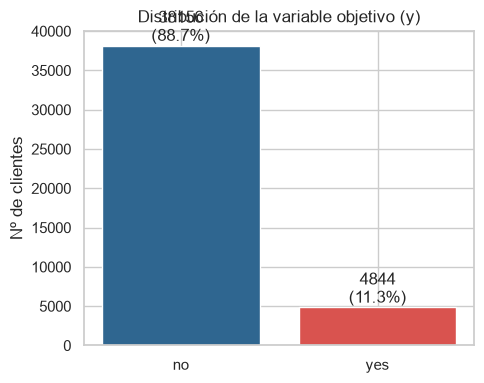

In [57]:
fig, ax = plt.subplots(figsize=(5, 4))
vc = c["y"].value_counts()
ax.bar(vc.index, vc.values, color=PALETA)
for i, v in enumerate(vc.values):
    ax.text(i, v, f"{v}\n({v/len(c):.1%})", ha="center", va="bottom")
ax.set_title("Distribución de la variable objetivo (y)")
ax.set_ylabel("Nº de clientes")
guarda(fig, "01_distribucion_y.png"); plt.show()

### 8.2 Conversión por profesión y por resultado de campaña previa

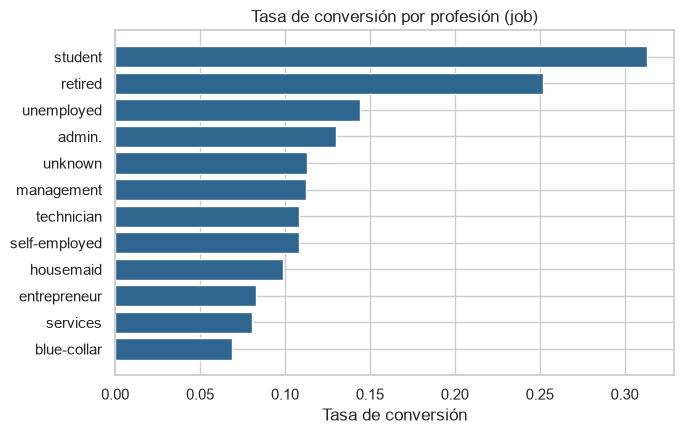

In [58]:
fig = barras_tasa("job", "Tasa de conversión por profesión (job)", horizontal=True)
guarda(fig, "02_conversion_job.png"); plt.show()

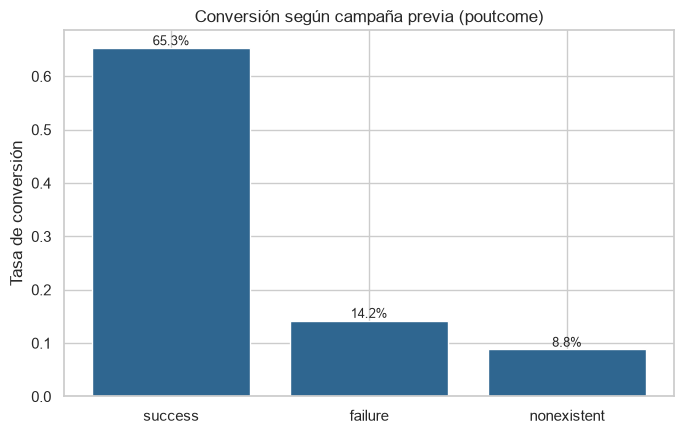

In [59]:
fig = barras_tasa("poutcome", "Conversión según campaña previa (poutcome)")
guarda(fig, "03_conversion_poutcome.png"); plt.show()

### 8.3 Edad y duración de la llamada según el resultado

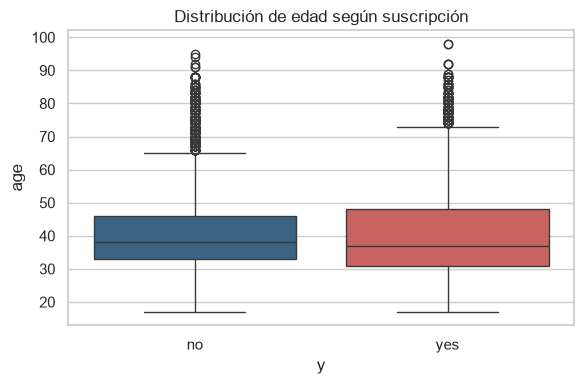

In [60]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=c, x="y", y="age", hue="y", palette=PALETA, legend=False, ax=ax)
ax.set_title("Distribución de edad según suscripción")
guarda(fig, "04_edad_por_y.png"); plt.show()

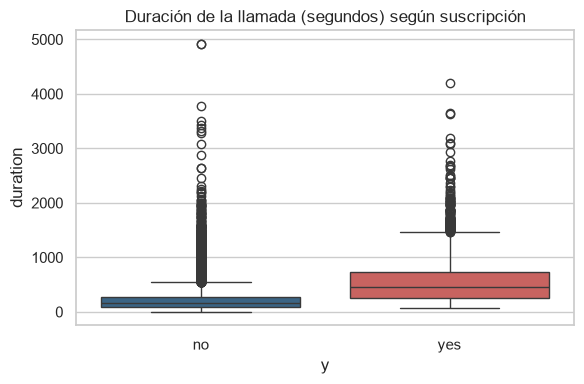

In [61]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=c, x="y", y="duration", hue="y", palette=PALETA, legend=False, ax=ax)
ax.set_title("Duración de la llamada (segundos) según suscripción")
guarda(fig, "05_duration_por_y.png"); plt.show()

> **Advertencia sobre `duration`.** Las llamadas de clientes que suscriben son mucho
> más largas, pero `duration` **solo se conoce al terminar la llamada**: no sirve para
> predecir *a priori* y, en un modelo, provocaría fuga de información. La incluimos
> como hallazgo descriptivo, no como palanca de acción.

### 8.4 Conversión por franja de edad

C:\Users\nesto\AppData\Local\Temp\ipykernel_5188\361753447.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen = (c.groupby(col)


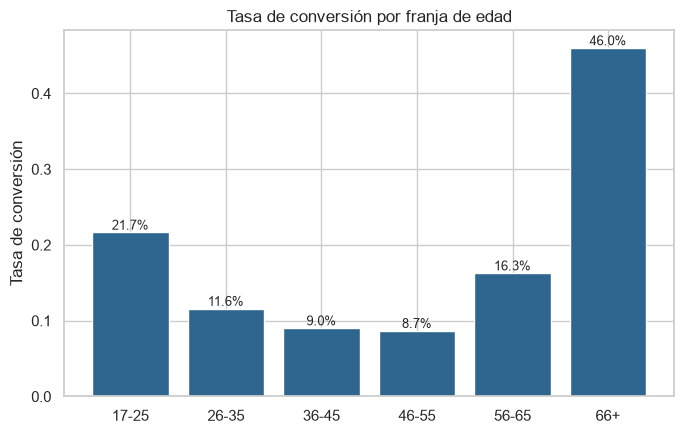

In [62]:
fig = barras_tasa("franja_edad", "Tasa de conversión por franja de edad", ordenar=False)
guarda(fig, "06_conversion_edad.png"); plt.show()

### 8.5 Euríbor y conversión en el tiempo

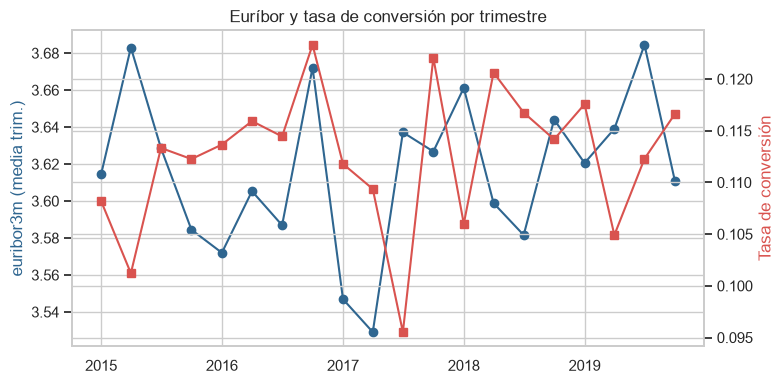

In [63]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(temporal.index, temporal["euribor"], color="#2f6690", marker="o", label="euribor3m")
ax1.set_ylabel("euribor3m (media trim.)", color="#2f6690")
ax2 = ax1.twinx()
ax2.plot(temporal.index, temporal["tasa"], color="#d9534f", marker="s", label="conversión")
ax2.set_ylabel("Tasa de conversión", color="#d9534f")
ax1.set_title("Euríbor y tasa de conversión por trimestre")
guarda(fig, "07_euribor_conversion_tiempo.png"); plt.show()

### 8.6 Matriz de correlaciones

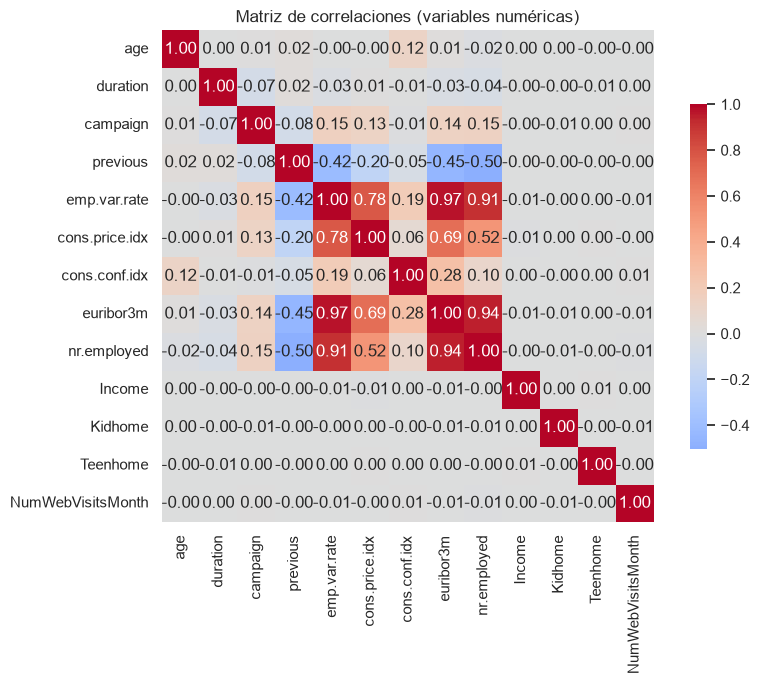

In [64]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Matriz de correlaciones (variables numéricas)")
guarda(fig, "08_correlaciones.png"); plt.show()

### 8.7 Ingresos según suscripción y grupos de préstamos

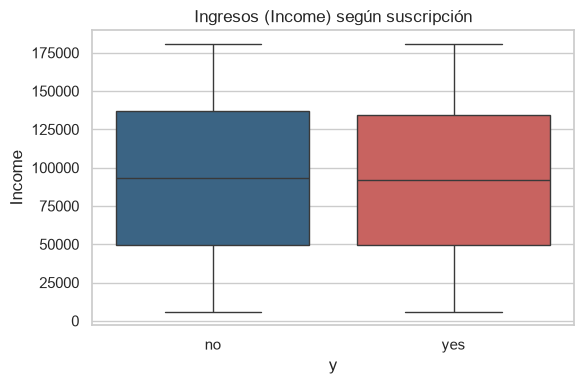

In [65]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=c, x="y", y="Income", hue="y", palette=PALETA, legend=False, ax=ax)
ax.set_title("Ingresos (Income) según suscripción")
guarda(fig, "09_income_por_y.png"); plt.show()

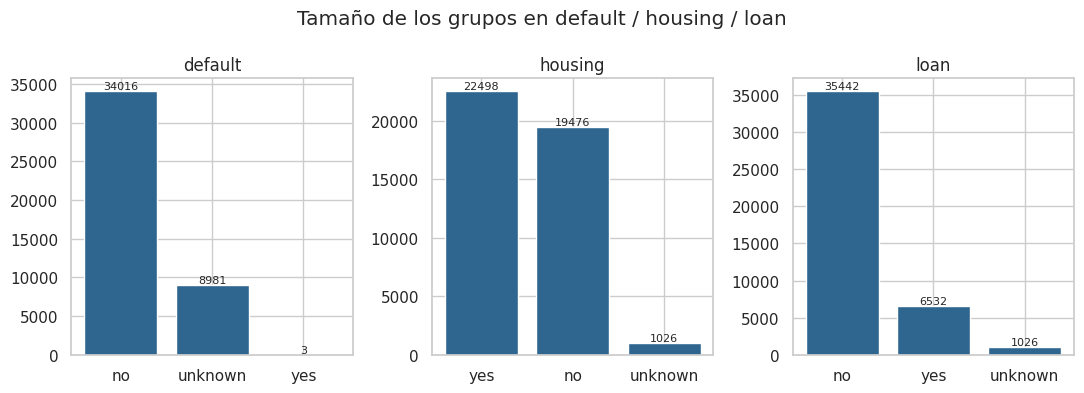

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, col in zip(axes, ["default", "housing", "loan"]):
    vc = c[col].value_counts()
    ax.bar(vc.index, vc.values, color="#2f6690")
    ax.set_title(col)
    for i, v in enumerate(vc.values):
        ax.text(i, v, str(v), ha="center", va="bottom", fontsize=8)
fig.suptitle("Tamaño de los grupos en default / housing / loan")
guarda(fig, "10_grupos_prestamos.png"); plt.show()

## 9. Informe y conclusiones

### Resumen del proceso
Partimos de dos fuentes (43.000 interacciones de campaña + 43.170 fichas de cliente en
un Excel de 3 hojas). Tras **limpiar** (columnas índice sobrantes, decimales con coma,
categóricas en mayúsculas, fechas en español, nulos tratados con criterio y coordenadas
sintéticas descartadas) y **unir** ambas fuentes por el identificador de cliente,
obtuvimos un dataset analizable de 43.000 registros con campaña y detectamos 170
clientes sin campaña.

### Principales hallazgos
1. **Problema desbalanceado**: solo el **11,3%** suscribe el depósito.
2. **El historial manda**: `poutcome == success` eleva la conversión al **65%**; haber
   sido contactado antes, al **64%**. La fidelización supera a cualquier variable de
   perfil.
3. **Canal**: el móvil convierte **casi el triple** que el teléfono fijo (14,7% vs 5,2%).
4. **Perfil demográfico**: `student` (31%) y `retired` (25%) son los mejores objetivos;
   la conversión por edad tiene forma de **U** (jóvenes y mayores de 65 arriba, edad
   media abajo). El nivel educativo alto también ayuda.
5. **Contexto macro**: con **euríbor bajo** la conversión sube (correlación −0,31). El
   bloque de indicadores macro está muy autocorrelacionado.
6. **El "dato ausente" informa**: en `default`, el grupo `unknown` convierte menos de la
   mitad que `no`; tratarlo como categoría (y no imputarlo) fue clave.
7. **Limitaciones detectadas**: `duration` no es utilizable como predictor (se conoce a
   posteriori); las coordenadas y la dimensión temporal parecen sintéticas; las
   variables demográficas del Excel no se relacionan con la conversión.

### Recomendaciones de negocio
- Priorizar a clientes con **campañas previas exitosas** y **contactar por móvil**.
- Segmentar por **estudiantes y jubilados** y, en general, por los **extremos de edad**.
- Aprovechar **ventanas de euríbor bajo** para intensificar las campañas.
- Recuperar la bolsa de **clientes nunca contactados** como objetivo de futuras acciones.